# C2C submission
Loads the checkpoint set declared by package_config, daily z-averages it and applies rank-gauss.

[2026-07-31 22:30:51] [info     ] score ready                    days=242 rows=241770
[2026-07-31 22:30:51] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-31 22:30:52] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-31 22:30:52] [info     ] 因子列名不为 factor, 自动重命名
[2026-07-31 22:30:52] [info     ] 未提供因子池，只进行单因子分析
[2026-07-31 22:30:52] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-31 22:30:52] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-07-31 22:30:52] [info     ] ========== 数据检查 ==========
[2026-07-31 22:30:52] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor']
[2026-07-31 22:30:52] [info     ] 通过：唯一性检查
[2026-07-31 22:30:52] [info     ] 通过：factor 有限值检查（禁止 inf/-inf）
[2026-07-31 22:30:52] [info     ] 通过：缺日检查（无整日全缺的交易日）
[2026-07-31 22:30:52] [info     ] 通过：覆盖度检查（每交易日缺失率<=40%）
[2026-07-31 22:30:52] [info     ] ========== 数据预处理 ==========
[2026-07-31 22:30:52] [info     ] inf 处理

时段,IC
2024-01-15~2024-02-08,0.0351
2024-09-24~2024-10-08,0.0808

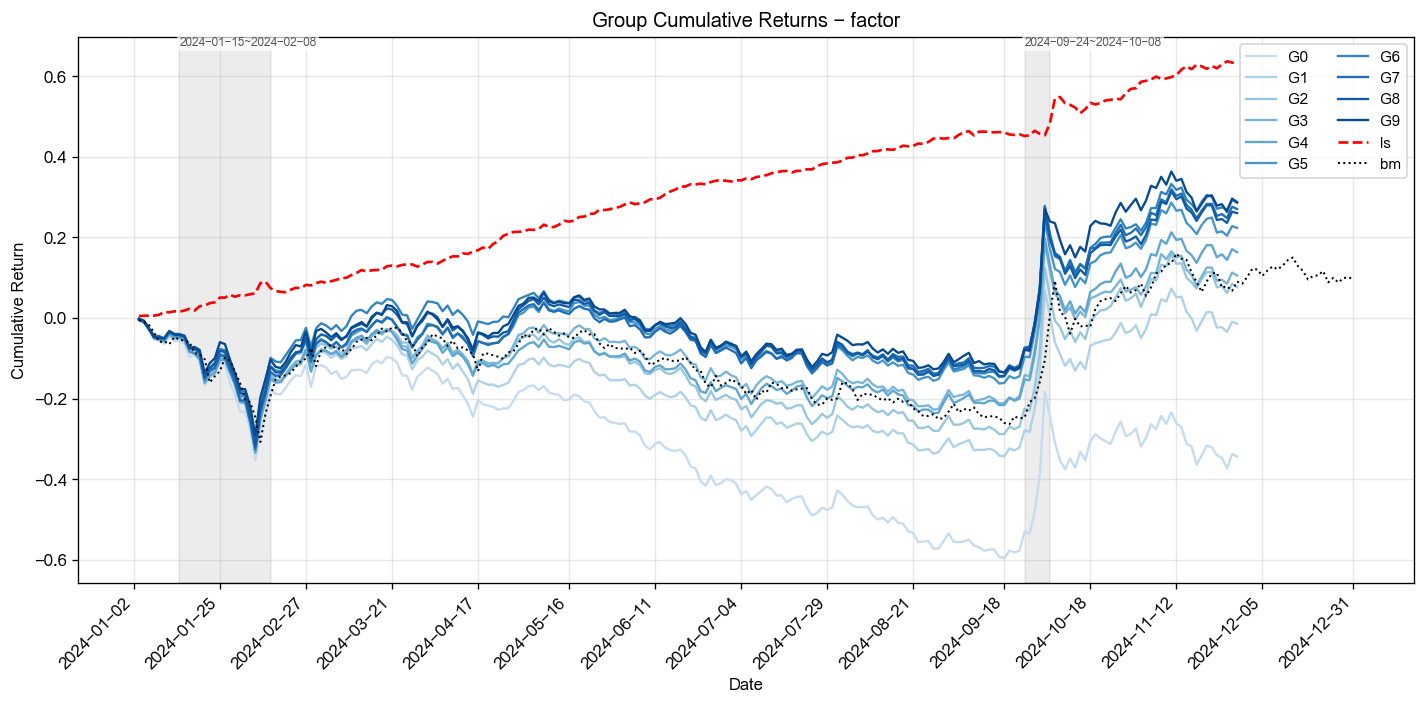
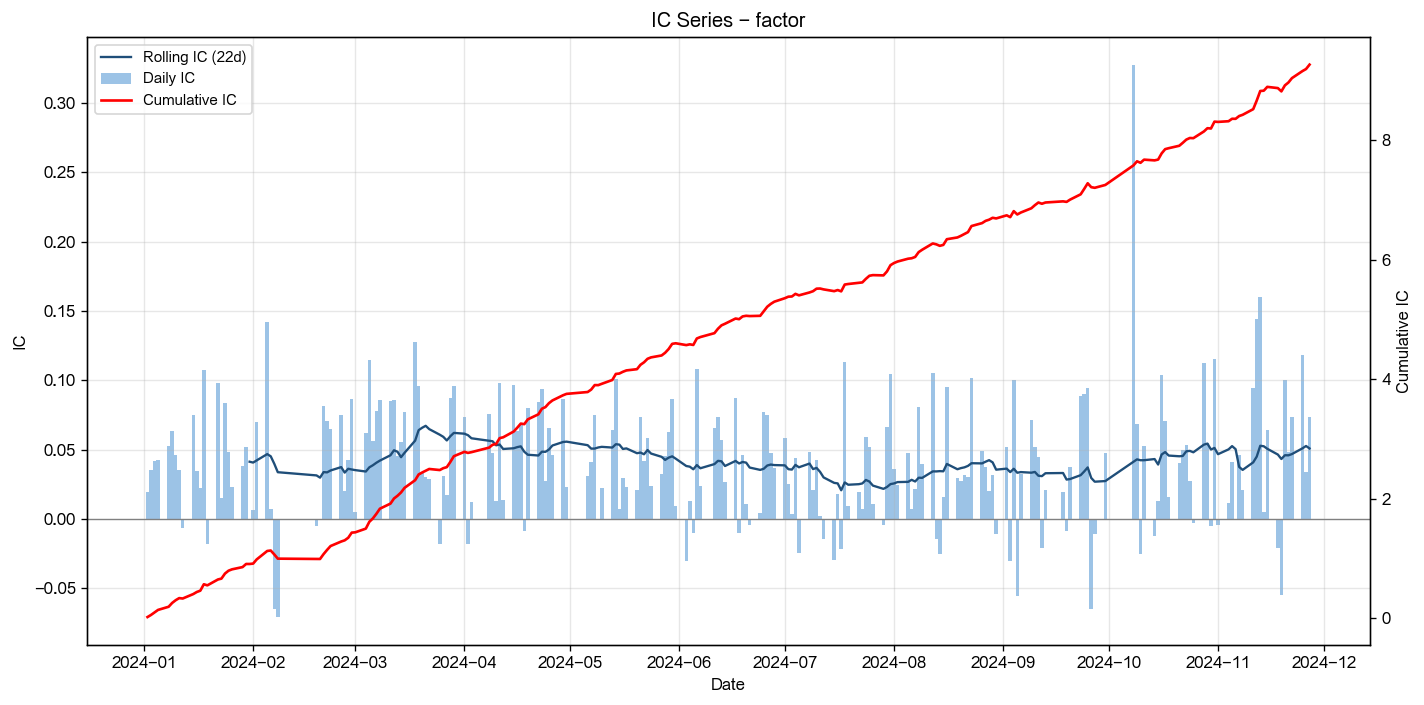
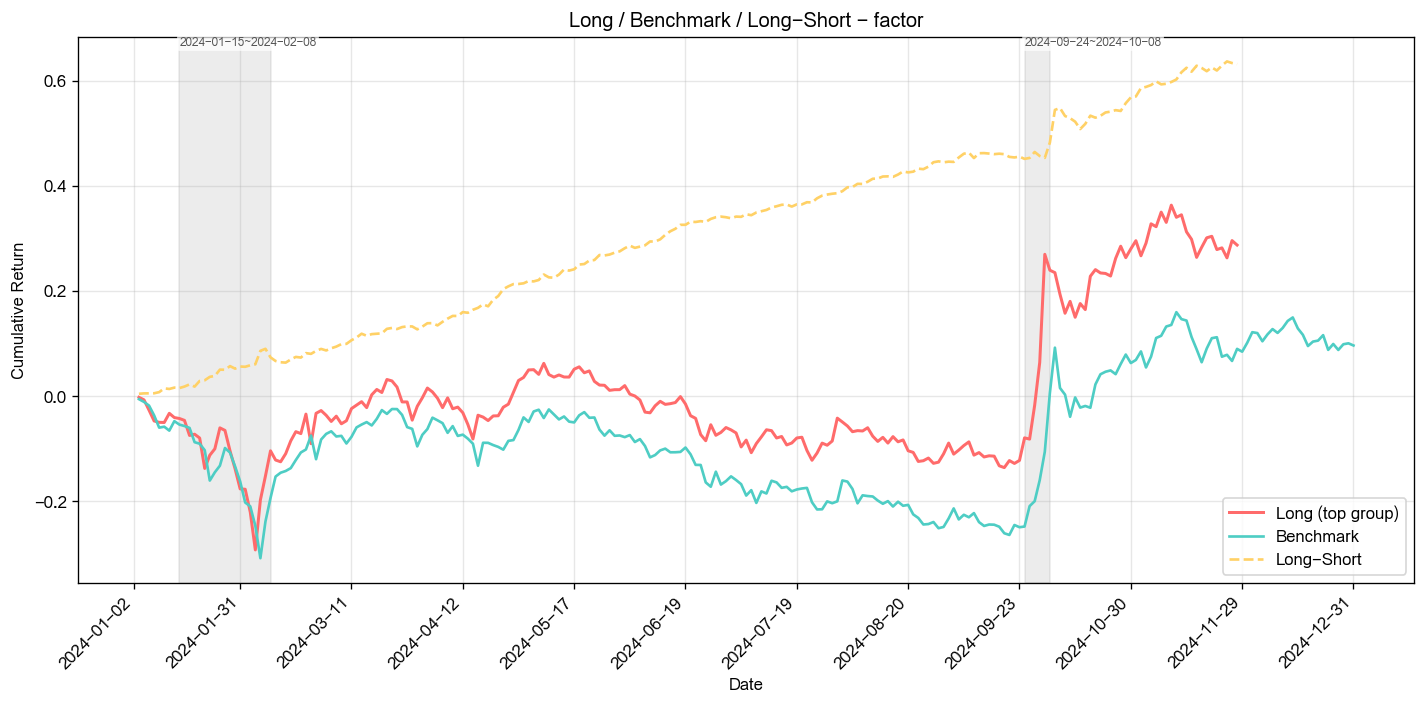
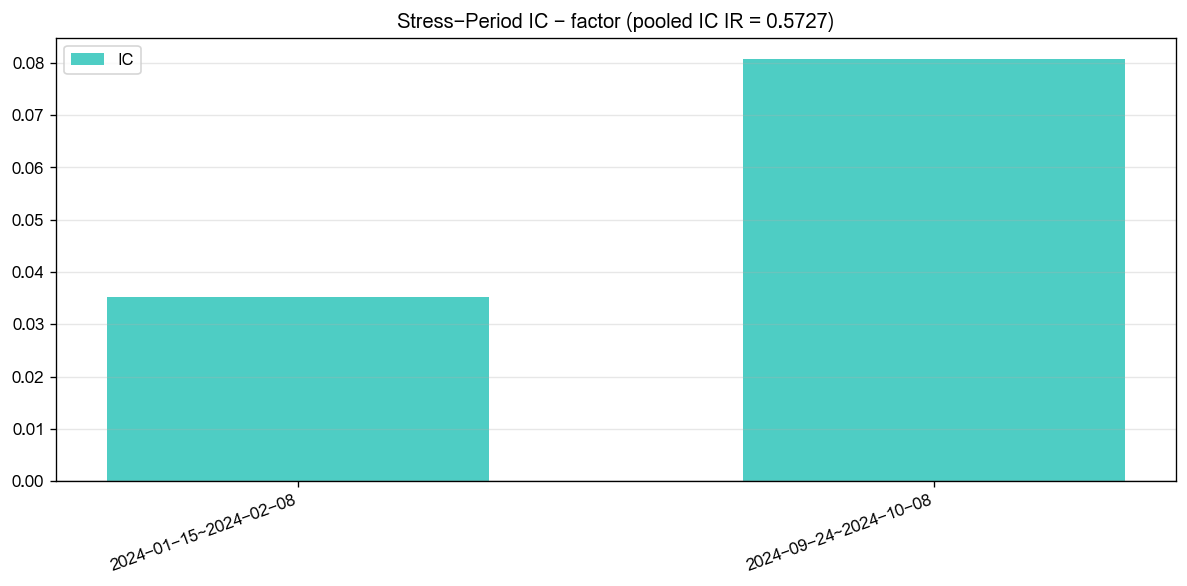
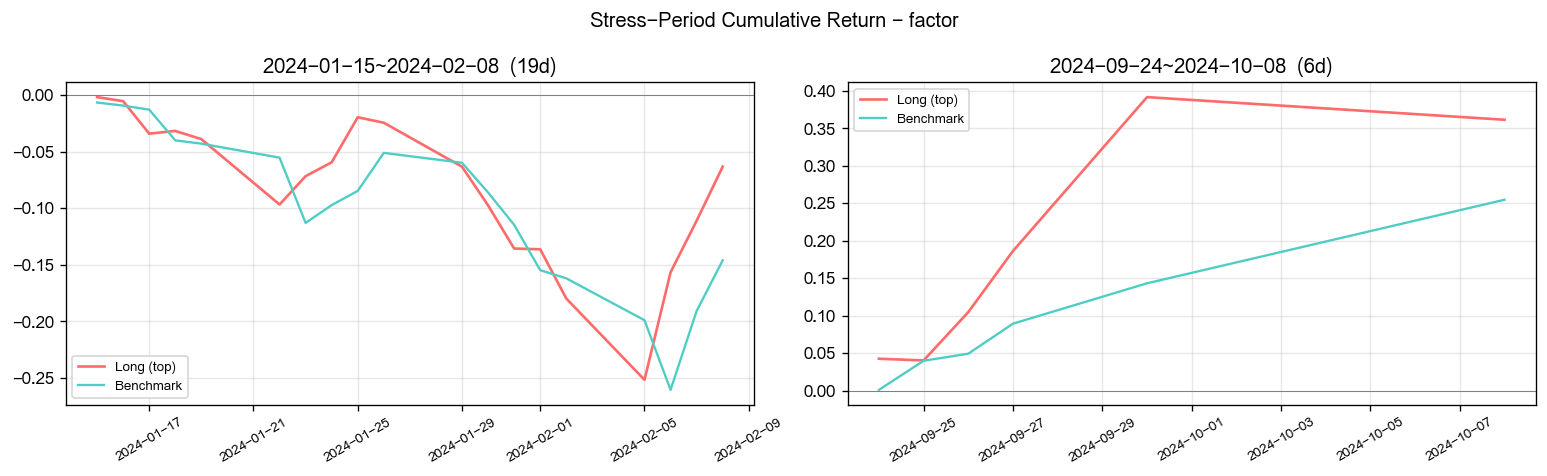

[2026-07-31 22:31:02] [warning  ] 未传入因子池，跳过因子池回归检验
[2026-07-31 22:31:03] [warning  ] 返回的Outputs实例(size=35319956) 大于 64K, 将不会被缓存
[2026-07-31 22:31:03] [info     ] bigalpha_eval.v4 运行完成 [11.281s].


In [2]:
import os
import numpy as np
import pandas as pd
import dai
import torch
import structlog
from transformer_train import BAR_KEY, SEEDS, TOP_K, model_path, predict_ensemble
logger = structlog.get_logger()

def main(datasources, start_date, end_date):
    table = datasources[BAR_KEY]
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    missing = [os.path.basename(model_path(s, k)) for s in SEEDS for k in range(1, TOP_K + 1) if not os.path.exists(model_path(s, k))]
    if missing:
        raise FileNotFoundError(f'缺少权重: {missing}')
    scores = predict_ensemble(table, start_date, end_date, device)
    stk = dai.query('SELECT date, instrument FROM bigalpha_2026_instruments', filters={'date': [start_date, end_date]}).df()
    result = (pd.merge(scores, stk, on=['date', 'instrument'], how='inner')
                .replace([np.inf, -np.inf], np.nan).dropna(subset=['score'])
                .drop_duplicates(['date', 'instrument'])[['date', 'instrument', 'score']]
                .reset_index(drop=True))
    logger.info('score ready', rows=len(result), days=result['date'].nunique())
    return result

if __name__ == '__main__':
    from bigmodule import M
    datasources = {BAR_KEY: f'bigalpha_2026_stock_{BAR_KEY}'}
    missing = [os.path.basename(model_path(s, k))
              for s in SEEDS for k in range(1, TOP_K + 1)
              if not os.path.exists(model_path(s, k))]
    if missing:
        raise FileNotFoundError(f'请先运行 platform_train.py 生成权重: {missing}')
    score_data = main(datasources, '2024-01-01 00:00:00', '2024-12-31 23:59:59')
    result = M.bigalpha_eval._latest(factor_data=score_data, show=True)